In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 0 — MOUNT GOOGLE DRIVE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — EXTRACT ZIP FROM DRIVE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import zipfile, os

# ✏️ EDIT THIS PATH ─────────────────────────────────────────────
zip_path = "/content/drive/MyDrive/Datasets/Gujarati_F&R_News.zip"
# ───────────────────────────────────────────────────────────────

extract_path = "/content/gujarati_news"

if not os.path.exists(zip_path):
    print(f'❌ ZIP not found: {zip_path}')
    print('\n📌 Update zip_path above to your actual location')
else:
    print(f'📦 Found: {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)')
    print(f'📂 Extracting to: {extract_path}')

    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)

    print('✅ Extracted')

    fake_path = os.path.join(extract_path, "Gujarati_fake_news")
    real_path = os.path.join(extract_path, "Gujarati_real_news")

    if not os.path.exists(fake_path):
        subdirs = [f.path for f in os.scandir(extract_path) if f.is_dir()]
        if subdirs:
            extract_path = subdirs[0]
            fake_path = os.path.join(extract_path, "Gujarati_fake_news")
            real_path = os.path.join(extract_path, "Gujarati_real_news")

    if os.path.exists(fake_path):
        fc = len([f for f in os.listdir(fake_path) if f.endswith('.txt') and not f.startswith('._')])
        print(f'   Fake: {fc:,} files')
    if os.path.exists(real_path):
        rc = len([f for f in os.listdir(real_path) if f.endswith('.txt') and not f.startswith('._')])
        print(f'   Real: {rc:,} files')
    print('\n→ Proceed to Cell 2')

📦 Found: /content/drive/MyDrive/Datasets/Gujarati_F&R_News.zip (42.8 MB)
📂 Extracting to: /content/gujarati_news
✅ Extracted
   Fake: 8,859 files
   Real: 8,800 files

→ Proceed to Cell 2


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — INSTALL PACKAGES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
!pip install transformers==4.40.0 -q
!pip install torch-geometric -q
!pip install torch-scatter torch-sparse -q \
    --find-links https://data.pyg.org/whl/torch-2.3.0+cu121.html
!pip install langdetect scikit-learn matplotlib seaborn -q

import os, gc, re, time, warnings, requests
import torch, numpy as np, pandas as pd
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

def free_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print('\n✅ CELL 2 done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 114.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.2 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 53.1 MB/s 

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD GUJARATI .TXT FILES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

if 'extract_path' not in globals():
    extract_path = "/content/gujarati_news"

fake_path = os.path.join(extract_path, "Gujarati_fake_news")
real_path = os.path.join(extract_path, "Gujarati_real_news")

if not os.path.exists(fake_path):
    for root, dirs, files in os.walk(extract_path):
        if "Gujarati_fake_news" in dirs:
            fake_path = os.path.join(root, "Gujarati_fake_news")
            real_path = os.path.join(root, "Gujarati_real_news")
            break

MAX_SAMPLES_PER_CLASS = 10000  # use all; reduce to 5000 for faster testing

texts  = []
labels = []

def load_data(folder, label):
    if not os.path.exists(folder):
        print(f'⚠️  Not found: {folder}')
        return 0
    files = [f for f in os.listdir(folder)
             if f.endswith(".txt") and not f.startswith("._")]
    if MAX_SAMPLES_PER_CLASS and len(files) > MAX_SAMPLES_PER_CLASS:
        files = files[:MAX_SAMPLES_PER_CLASS]
    lbl_name = "Fake" if label == 1 else "Real"
    print(f'📄 Loading {len(files):,} {lbl_name} articles...')
    for file in tqdm(files, desc=f"   {lbl_name}"):
        try:
            with open(os.path.join(folder, file), "r",
                      encoding="utf-8", errors="ignore") as f:
                text = f.read().strip()
            if len(text) > 20:
                texts.append(text)
                labels.append(label)
        except:
            continue
    return len([t for t in texts if labels[texts.index(t)] == label])

fake_loaded = load_data(fake_path, 1)
real_loaded = load_data(real_path, 0)

print(f'\n✅ Total: {len(texts):,} (Fake:{fake_loaded:,} | Real:{real_loaded:,})')

df = pd.DataFrame({"text": texts, "label": labels})
n_min = df['label'].value_counts().min()
df = pd.concat([
    df[df['label']==0].sample(n_min, random_state=42),
    df[df['label']==1].sample(n_min, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'📊 Balanced: {len(df):,} ({n_min:,} fake + {n_min:,} real)')

# ── Text Cleaning ──────────────────────────────────────────────
def clean_text(text):
    text = str(text).strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

print('🧹 Cleaning...')
df['text'] = df['text'].apply(clean_text)
df = df[df['text'].str.len() > 20].reset_index(drop=True)

# ── Gujarati NER (regex-based) ─────────────────────────────────
# Gujarati script: ગુજરાતી
ENTITY_PATTERNS = {
    'PERSON'  : r'\b[A-Z][a-z]+ [A-Z][a-z]+\b',
    'ORG'     : r'\b(સરકાર|સંસદ|ન્યાયાલય|ઇસરો|ભાજપ|કોંગ્રેસ|મંત્રાલય|Government|Parliament|Court|ISRO|BJP|INC|Ministry)\b',
    'LOCATION': r'\b(ભારત|દિલ્હી|મુંબઈ|અમદાવાદ|સુરત|રાજકોટ|ગાંધીનગર|India|Delhi|Mumbai|Ahmedabad|Surat|Rajkot|Gandhinagar)\b',
    'DATE'    : r'\b(જાન્યુઆરી|ફેબ્રુઆરી|માર્ચ|એપ્રિલ|મે|જૂન|જુલાઈ|ઓગસ્ટ|સપ્ટેમ્બર|ઓક્ટોબર|નવેમ્બર|ડિસેમ્બર|January|February|March|April|May|June|July|August|September|October|November|December|\d{4})\b',
}

def extract_entities(text):
    entities, seen = [], set()
    for etype, pattern in ENTITY_PATTERNS.items():
        for m in re.findall(pattern, text):
            if isinstance(m, tuple): m = m[0]
            if (m, etype) not in seen:
                entities.append({'text': m, 'type': etype})
                seen.add((m, etype))
    return entities

# ── Gujarati Credibility Keywords ─────────────────────────────
CRED_KW = {
    'fake': ['ગુપ્ત','ખુલાસો','રહસ્ય','ચોંકાવનારું','ષડયંત્ર','વાયરલ',
             'secretly','exposed','whistleblower','shocking','conspiracy','hidden'],
    'real': ['સંસદ','ન્યાયાલય','સત્તાવાર','અહેવાલ','સરકારે જણાવ્યું','મંત્રાલય',
             'parliament','court','official','confirmed','published','report','ministry']
}

def credibility_signal(text):
    tl = text.lower()
    fk = sum(1 for kw in CRED_KW['fake'] if kw in tl)
    rl = sum(1 for kw in CRED_KW['real'] if kw in tl)
    tot = fk + rl
    return 0.5 if tot == 0 else rl / tot

print('🔍 Extracting entities...')
df['language']           = 'gu'  # Gujarati ISO code
df['entities']           = df['text'].apply(extract_entities)
df['entity_count']       = df['entities'].apply(len)
df['credibility_signal'] = df['text'].apply(credibility_signal)

print(f'\n✅ Ready: {len(df):,} samples')
print(f'   Avg entities : {df["entity_count"].mean():.1f}')
print(f'   Avg length   : {df["text"].str.len().mean():.0f} chars')

print('\n📋 Sample:')
for idx in df.sample(3, random_state=42).index:
    row = df.loc[idx]
    lbl = '🚨 FAKE' if row['label']==1 else '✅ REAL'
    print(f'\n{lbl}: {row["text"][:100]}...')
    if row['entities']:
        print(f'     Entities: {[e["text"] for e in row["entities"][:3]]}')

free_memory()
print('\n✅ CELL 3 done')

📄 Loading 8,859 Fake articles...


   Fake:   0%|          | 0/8859 [00:00<?, ?it/s]

📄 Loading 8,800 Real articles...


   Real:   0%|          | 0/8800 [00:00<?, ?it/s]


✅ Total: 17,657 (Fake:8,857 | Real:8,800)
📊 Balanced: 17,600 (8,800 fake + 8,800 real)
🧹 Cleaning...
🔍 Extracting entities...

✅ Ready: 17,600 samples
   Avg entities : 3.6
   Avg length   : 2692 chars

📋 Sample:

🚨 FAKE: અલગુલ ગાંધીની અલગ મત્સ્યઉદ્યોગ મંત્રાલયની માંગ ફેક્ટરચેકિંગ રાહુલ ગાંધીએ ફરી એકવાર ફિશરીઝ મંત્રાલયની...
     Entities: ['મંત્રાલય', 'સરકાર', 'કોંગ્રેસ']

✅ REAL: ‘ગીત ગાતા ચલ’ જસપાલ સિંહ ગાયક તરીકે રાજશ્રીની ‘ગીત ગાતા ચલ’ (૧૯૭૫) થી જાણીતા થનાર જસપાલ સિંહને ફિલ્મ...
     Entities: ['૧૯૭૫', 'મે', '૧૯૬૮']

✅ REAL: અફઘાનિસ્તાનમાં તાલીબાનના રાજથી પાકિસ્તાન ખુશજણાવ્યું કે…. પાકિસ્તાનના ગૃહ પ્રધાન શેખ રશીદ અહમદે અફઘા...
     Entities: ['સરકાર']

✅ CELL 3 done


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — XLM-R EMBEDDINGS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = 'xlm-roberta-base'
MAX_LEN    = 128
BATCH_SIZE = 8

print(f'🤖 Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
xlm       = AutoModel.from_pretrained(MODEL_NAME).to(device)
xlm.eval()
print(f'✅ Loaded on {device}')

def mean_pool(hidden, mask):
    m = mask.unsqueeze(-1).float()
    return (hidden * m).sum(1) / m.sum(1).clamp(min=1e-9)

def embed_batch(texts):
    all_emb = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='Embedding'):
        batch = texts[i:i+BATCH_SIZE]
        enc   = tokenizer(batch, padding=True, truncation=True,
                          max_length=MAX_LEN, return_tensors='pt')
        ids   = enc['input_ids'].to(device)
        mask  = enc['attention_mask'].to(device)
        with torch.no_grad():
            out = xlm(input_ids=ids, attention_mask=mask)
        emb = mean_pool(out.last_hidden_state, mask).cpu().numpy()
        all_emb.append(emb)
        del ids, mask, out, emb
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.vstack(all_emb)

print(f'\n🔄 Embedding {len(df):,} articles...')
embeddings = embed_batch(df['text'].tolist())
print(f'✅ {embeddings.shape}')

del xlm
free_memory()
print('\n✅ CELL 4 done')

🤖 Loading xlm-roberta-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

✅ Loaded on cuda

🔄 Embedding 17,600 articles...


Embedding:   0%|          | 0/2200 [00:00<?, ?it/s]

✅ (17600, 768)

✅ CELL 4 done


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — WIKIDATA FACT NODES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WD_API  = 'https://www.wikidata.org/w/api.php'
HEADERS = {'User-Agent': 'FakeNewsDetector/1.0 (REVA)'}
CACHE   = {}

def query_wikidata(entity_text, lang='gu'):
    key = f'{entity_text}_{lang}'
    if key in CACHE: return CACHE[key]
    try:
        r = requests.get(WD_API,
              params={'action':'wbsearchentities','format':'json',
                      'language':lang,'search':entity_text,'limit':1,'type':'item'},
              headers=HEADERS, timeout=5)
        data = r.json()
        if data.get('search'):
            hit  = data['search'][0]
            info = {'id':hit.get('id',''),'label':hit.get('label',entity_text),
                    'description':hit.get('description',''),'verified':True}
        else:
            info = {'id':'','label':entity_text,'description':'Not in Wikidata','verified':False}
        CACHE[key] = info
        time.sleep(0.08)
        return info
    except:
        fallback = {'id':'','label':entity_text,'description':'Query failed','verified':False}
        CACHE[key] = fallback
        return fallback

def build_fact_nodes(df, max_ents=3):
    facts = []
    for idx in tqdm(df.index, desc='Wikidata'):
        row = df.loc[idx]
        for ent in row['entities'][:max_ents]:
            wk = query_wikidata(ent['text'], lang='gu')
            facts.append({
                'sample_idx':idx, 'entity_text':ent['text'], 'entity_type':ent['type'],
                'wikidata_id':wk['id'], 'description':wk['description'], 'verified':wk['verified']
            })
    return facts

print(f'🌐 Querying Wikidata for {len(df):,} articles...')
fact_list = build_fact_nodes(df, max_ents=3)
fact_df   = pd.DataFrame(fact_list)

print(f'\n✅ Fact nodes: {len(fact_df):,}')
print(f'   Verified  : {fact_df["verified"].sum():,} ({fact_df["verified"].mean()*100:.1f}%)')

free_memory()
print('\n✅ CELL 5 done')

🌐 Querying Wikidata for 17,600 articles...


Wikidata:   0%|          | 0/17600 [00:00<?, ?it/s]


✅ Fact nodes: 39,597
   Verified  : 36,381 (91.9%)

✅ CELL 5 done


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — HETEROGENEOUS GRAPH
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from torch_geometric.data import HeteroData

FEAT_DIM = 769

cred_t    = torch.tensor(df['credibility_signal'].fillna(0.5).values.reshape(-1,1), dtype=torch.float)
art_feats = torch.cat([torch.tensor(embeddings,dtype=torch.float), cred_t], dim=1)

ent_vocab = {}
etype_map = {'PERSON':0,'ORG':1,'LOCATION':2,'DATE':3}
for row_ents in df['entities']:
    for e in row_ents:
        if e['text'] not in ent_vocab:
            ent_vocab[e['text']] = {'id':len(ent_vocab),'type_idx':etype_map.get(e['type'],0)}
N_ENT = len(ent_vocab)
np.random.seed(42)
ent_oh   = np.zeros((N_ENT,4),dtype=np.float32)
for ev in ent_vocab.values(): ent_oh[ev['id'],ev['type_idx']]=1.0
ent_rand = np.random.randn(N_ENT,FEAT_DIM-4).astype(np.float32)*0.01
ent_feats= torch.tensor(np.concatenate([ent_oh,ent_rand],axis=1),dtype=torch.float)

uniq_facts = fact_df.drop_duplicates('entity_text').reset_index(drop=True)
N_FACT     = len(uniq_facts)
fact_ver   = uniq_facts['verified'].astype(float).values.reshape(-1,1)
np.random.seed(99)
fact_rand  = np.random.randn(N_FACT,FEAT_DIM-1).astype(np.float32)*0.01
fact_feats = torch.tensor(np.concatenate([fact_ver.astype(np.float32),fact_rand],axis=1),dtype=torch.float)

ae_s,ae_d = [],[]
for idx,row in df.iterrows():
    for e in row['entities']:
        if e['text'] in ent_vocab:
            ae_s.append(idx); ae_d.append(ent_vocab[e['text']]['id'])

fmap = {r['entity_text']:i for i,r in uniq_facts.iterrows()}
ef_s,ef_d = [],[]
for et,ev in ent_vocab.items():
    if et in fmap: ef_s.append(ev['id']); ef_d.append(fmap[et])

af_s,af_d = [],[]
for idx,row in df.iterrows():
    for e in row['entities']:
        if e['text'] in fmap: af_s.append(idx); af_d.append(fmap[e['text']])

def ei(s,d):
    return torch.tensor([s,d],dtype=torch.long) if s else torch.zeros((2,0),dtype=torch.long)

graph = HeteroData()
graph['article'].x = art_feats
graph['entity'].x  = ent_feats
graph['fact'].x    = fact_feats
graph['article'].y = torch.tensor(df['label'].values,dtype=torch.long)

graph['article','mentions','entity'].edge_index      = ei(ae_s,ae_d)
graph['article','supported_by','fact'].edge_index    = ei(af_s,af_d)
graph['entity','linked_to','fact'].edge_index        = ei(ef_s,ef_d)
graph['entity','mentioned_in','article'].edge_index  = ei(ae_d,ae_s)
graph['fact','supports','entity'].edge_index         = ei(ef_d,ef_s)

print('✅ Graph built')
print(f'   Articles: {art_feats.shape[0]:>7,}')
print(f'   Entities: {N_ENT:>7,}')
print(f'   Facts   : {N_FACT:>7,}')
print(f'   Edges   : {len(ae_s)+len(af_s)+len(ef_s):>7,}')

free_memory()
print('\n✅ CELL 6 done')

✅ Graph built
   Articles:  17,600
   Entities:   1,764
   Facts   :   1,073
   Edges   : 126,368

✅ CELL 6 done


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — R-GCN TRAINING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv
from sklearn.model_selection import train_test_split

IN_DIM  = FEAT_DIM
HIDDEN  = 128
EPOCHS  = 60
LR      = 1e-3
DROPOUT = 0.3

EDGE_TYPES = [
    ('article','mentions','entity'),
    ('article','supported_by','fact'),
    ('entity','mentioned_in','article'),
    ('entity','linked_to','fact'),
    ('fact','supports','entity'),
]

class HeteroRGCN(nn.Module):
    def __init__(self, in_dim, hidden, out_dim=2, dropout=0.3):
        super().__init__()
        self.conv1 = HeteroConv({et:SAGEConv(in_dim,hidden,normalize=True) for et in EDGE_TYPES},aggr='sum')
        self.conv2 = HeteroConv({et:SAGEConv(hidden,hidden,normalize=True) for et in EDGE_TYPES},aggr='sum')
        self.head  = nn.Sequential(nn.Linear(hidden,64),nn.ReLU(),nn.Dropout(dropout),nn.Linear(64,out_dim))
        self.drop  = dropout
    def forward(self,x_dict,ei_dict):
        x = self.conv1(x_dict,ei_dict)
        x = {k:F.dropout(F.relu(v),self.drop,self.training) for k,v in x.items()}
        x = self.conv2(x,ei_dict)
        x = {k:F.relu(v) for k,v in x.items()}
        return self.head(x['article']),x

N = graph['article'].x.shape[0]
labs = graph['article'].y.numpy()
idx_tr,idx_te = train_test_split(np.arange(N),test_size=0.2,stratify=labs,random_state=42)
idx_tr,idx_va = train_test_split(idx_tr,test_size=0.2,stratify=labs[idx_tr],random_state=42)

def mk(idx): m=torch.zeros(N,dtype=torch.bool); m[idx]=True; return m.to(device)
tr_mask,va_mask,te_mask = mk(idx_tr),mk(idx_va),mk(idx_te)
print(f'Split → Train:{tr_mask.sum()} | Val:{va_mask.sum()} | Test:{te_mask.sum()}')

graph = graph.to(device)
model = HeteroRGCN(IN_DIM,HIDDEN).to(device)
opt   = torch.optim.Adam(model.parameters(),lr=LR,weight_decay=1e-4)
crit  = nn.CrossEntropyLoss()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out,_ = model(graph.x_dict,graph.edge_index_dict)
    preds = out[mask].argmax(1)
    labs  = graph['article'].y[mask]
    return (preds==labs).float().mean().item(), crit(out[mask],labs).item()

print(f'\n🚀 Training {EPOCHS} epochs...')
print(f'{"Ep":>4} {"TrLoss":>8} {"VaLoss":>8} {"VaAcc":>7}')
print('─'*35)

best_acc,best_state = 0.0,None
history = {'tl':[],'vl':[],'va':[]}

for ep in range(1,EPOCHS+1):
    model.train()
    opt.zero_grad()
    out,_ = model(graph.x_dict,graph.edge_index_dict)
    loss  = crit(out[tr_mask],graph['article'].y[tr_mask])
    loss.backward(); opt.step()
    tl = loss.item()
    va,vl = evaluate(va_mask)
    history['tl'].append(tl); history['vl'].append(vl); history['va'].append(va)
    if va>best_acc:
        best_acc=va
        best_state={k:v.clone() for k,v in model.state_dict().items()}
    if ep%10==0 or ep==1:
        print(f'{ep:>4} {tl:>8.4f} {vl:>8.4f} {va:>6.2%}')

model.load_state_dict(best_state)
te_acc,_ = evaluate(te_mask)
print(f'\n{"="*35}')
print(f'✅ Best Val : {best_acc:.2%}')
print(f'✅ Test Acc : {te_acc:.2%}')

free_memory()
print('\n✅ CELL 7 done')

Split → Train:11264 | Val:2816 | Test:3520
Parameters: 1,157,826

🚀 Training 60 epochs...
  Ep   TrLoss   VaLoss   VaAcc
───────────────────────────────────
   1   0.6930   0.6916 69.03%
  10   0.6643   0.6508 77.13%
  20   0.5985   0.5790 80.54%
  30   0.4408   0.4240 93.25%
  40   0.2993   0.2747 95.85%
  50   0.1841   0.1698 97.41%
  60   0.1119   0.1126 97.76%

✅ Best Val : 98.22%
✅ Test Acc : 97.98%

✅ CELL 7 done


📊 GUJARATI FAKE NEWS DETECTION — RESULTS
              precision    recall  f1-score   support

        Real       0.98      0.98      0.98      1760
        Fake       0.98      0.98      0.98      1760

    accuracy                           0.98      3520
   macro avg       0.98      0.98      0.98      3520
weighted avg       0.98      0.98      0.98      3520

ROC-AUC  : 0.9966
F1-Macro : 0.9798


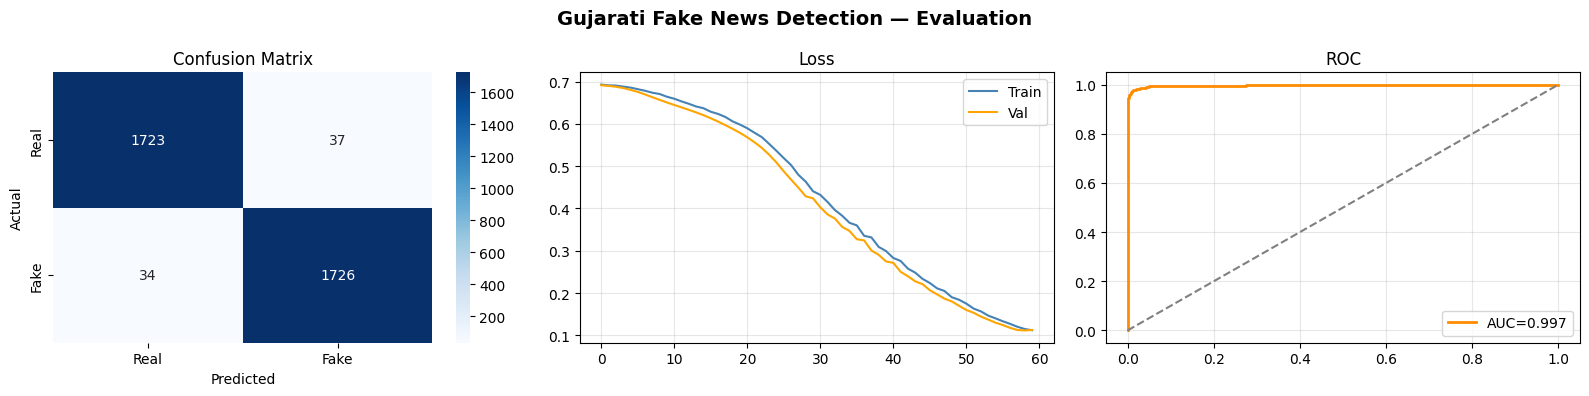

💾 /content/gujarati_eval.png

🔍 EXPLAINABILITY

─── #3 ────────────────────────────────────────────────
અંગ્રેજોના જમાનામાં જાહેરાતોમાં મહિલાઓને કેવી રીતે ટાર્ગેટ કરવામાં આવી હતી? અંગ્રેજોના જમાનામાં જાહેરાતોમાં મહિલાઓને કેવ...
True:✅ REAL | Pred:✅ REAL (95.0%)
Evidence:
  ✔ [ORG] સંસદ
  ✔ [LOCATION] ભારત
  ✔ [DATE] મે
  ✔ [DATE] સપ્ટેમ્બર
────────────────────────────────────────────────────────────

─── #4 ────────────────────────────────────────────────
કરડો નહીં, પણ ફૂંફાડો તો રાખો જ કરડો નહીં, પણ ફૂંફાડો તો રાખોમૂળ વાત એવી છે કે એક ઝાડની બખોલમાં ભયંકર સાપ રહેતો હતો.સાપ ...
True:✅ REAL | Pred:✅ REAL (95.1%)
Evidence:
  ✔ [DATE] મે
────────────────────────────────────────────────────────────

─── #6 ────────────────────────────────────────────────
/ કેનેડામાં સ્વામિનારાયણ મંદિરમાં ખાલિસ્તાની સૂત્રો લખાયા, ભારત કહ્યું, – કેનેડામાં ફરી એકવાર મંદિરને નિશાન બનાવવામાં આવ...
True:✅ REAL | Pred:✅ REAL (74.4%)
Evidence:
  ✔ [LOCATION] ભારત
────────────────────────────────────────────────────

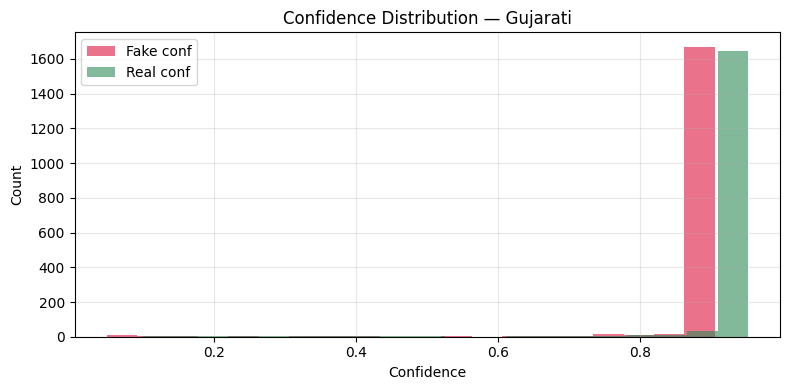

💾 /content/gujarati_conf.png

🎉 ALL DONE! Download plots for IEEE paper.


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — EVALUATION + EXPLAINABILITY
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve,f1_score

model.eval()
@torch.no_grad()
def get_preds(mask):
    out,embs = model(graph.x_dict,graph.edge_index_dict)
    probs = torch.softmax(out[mask],1).cpu().numpy()
    labs  = graph['article'].y[mask].cpu().numpy()
    return probs.argmax(1),probs,labs,embs

preds,probs,true_labs,embs = get_preds(te_mask)
auc = roc_auc_score(true_labs,probs[:,1])
f1  = f1_score(true_labs,preds,average='macro')

print('='*60)
print('📊 GUJARATI FAKE NEWS DETECTION — RESULTS')
print('='*60)
print(classification_report(true_labs,preds,target_names=['Real','Fake']))
print(f'ROC-AUC  : {auc:.4f}')
print(f'F1-Macro : {f1:.4f}')

fig,axes=plt.subplots(1,3,figsize=(16,4))
fig.suptitle('Gujarati Fake News Detection — Evaluation',fontsize=14,fontweight='bold')

cm=confusion_matrix(true_labs,preds)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Real','Fake'],yticklabels=['Real','Fake'],ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

axes[1].plot(history['tl'],label='Train',color='steelblue')
axes[1].plot(history['vl'],label='Val',color='orange')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

fpr,tpr,_=roc_curve(true_labs,probs[:,1])
axes[2].plot(fpr,tpr,color='darkorange',lw=2,label=f'AUC={auc:.3f}')
axes[2].plot([0,1],[0,1],'--',color='grey')
axes[2].set_title('ROC'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/gujarati_eval.png',dpi=150,bbox_inches='tight')
plt.show()
print('💾 /content/gujarati_eval.png')

print('\n'+'='*60)
print('🔍 EXPLAINABILITY')
print('='*60)

LMAP={0:'✅ REAL',1:'🚨 FAKE'}

@torch.no_grad()
def explain(sample_idx):
    row=df.iloc[sample_idx]
    out,_=model(graph.x_dict,graph.edge_index_dict)
    pr=torch.softmax(out[sample_idx],0).cpu().numpy()
    pred=int(pr.argmax())
    print(f'\n─── #{sample_idx} '+'─'*48)
    print(f'{row["text"][:120]}...')
    print(f'True:{LMAP[row["label"]]} | Pred:{LMAP[pred]} ({pr[pred]:.1%})')
    ents=row['entities']
    if ents:
        print('Evidence:')
        for e in ents[:4]:
            fr=fact_df[fact_df['entity_text']==e['text']]
            s='✔' if len(fr)>0 and fr.iloc[0]['verified'] else '✘'
            print(f'  {s} [{e["type"]}] {e["text"]}')
    print('─'*60)

te_idx=np.where(te_mask.cpu().numpy())[0][:6]
for i in te_idx: explain(int(i))

fig,ax=plt.subplots(figsize=(8,4))
ax.hist(probs[true_labs==1,1],bins=20,alpha=0.6,color='crimson',label='Fake conf')
ax.hist(probs[true_labs==0,0],bins=20,alpha=0.6,color='seagreen',label='Real conf')
ax.set_xlabel('Confidence'); ax.set_ylabel('Count')
ax.set_title('Confidence Distribution — Gujarati'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/gujarati_conf.png',dpi=150,bbox_inches='tight')
plt.show()
print('💾 /content/gujarati_conf.png')

free_memory()
print('\n🎉 ALL DONE! Download plots for IEEE paper.')

In [13]:
import torch
import os

# Define the path to save the model
MODEL_SAVE_PATH = '/content/drive/MyDrive/fake_news_project/hetero_rgcn_model_G.pth'

# Ensure the parent directory exists
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

# Save the model's state dictionary
torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f'✅ Model saved to: {MODEL_SAVE_PATH}')

✅ Model saved to: /content/drive/MyDrive/fake_news_project/hetero_rgcn_model_G.pth
